In [56]:
import tensorflow as tf
from tensorflow.keras import layers
import numpy as np
import matplotlib.pyplot as plt
import os

# Parámetros
z_dim = 100
epochs = 10
batch_size = 100
lr = 2e-4

# Cargar y preparar MNIST
(x_train, _), _ = tf.keras.datasets.mnist.load_data()
x_train = x_train[:10000]
x_train = (x_train.astype("float32") - 127.5) / 127.5  # Normalizar entre [-1, 1]
x_train = np.expand_dims(x_train, axis=-1)
dataset = tf.data.Dataset.from_tensor_slices(x_train).shuffle(6000).batch(batch_size).prefetch(tf.data.AUTOTUNE)

# Generador
def build_generator():
    model = tf.keras.Sequential([
        layers.Input(shape=(z_dim,)),
        layers.Dense(7 * 7 * 256, use_bias=False),
        layers.BatchNormalization(),
        layers.LeakyReLU(),

        layers.Reshape((7, 7, 256)),
        layers.Conv2DTranspose(128, kernel_size=5, strides=1, padding='same', use_bias=False),
        layers.BatchNormalization(),
        layers.LeakyReLU(),

        layers.Conv2DTranspose(64, kernel_size=5, strides=2, padding='same', use_bias=False),
        layers.BatchNormalization(),
        layers.LeakyReLU(),

        layers.Conv2DTranspose(1, kernel_size=5, strides=2, padding='same', use_bias=False, activation='tanh')
    ])
    return model

# Discriminador
def build_discriminator():
    model = tf.keras.Sequential([
        layers.Input(shape=(28, 28, 1)),
        layers.Conv2D(64, 5, strides=2, padding='same'),
        layers.LeakyReLU(),
        layers.Dropout(0.3),

        layers.Conv2D(128, 5, strides=2, padding='same'),
        layers.LeakyReLU(),
        layers.Dropout(0.3),

        layers.Flatten(),
        layers.Dense(1)  # logits
    ])
    return model


In [57]:

# Crear modelos
generator = build_generator()
discriminator = build_discriminator()

# Optimizadores
gen_optimizer = tf.keras.optimizers.Adam(lr, beta_1=0.5)
disc_optimizer = tf.keras.optimizers.Adam(lr, beta_1=0.5)

# Función de pérdida
cross_entropy = tf.keras.losses.BinaryCrossentropy(from_logits=True)

# Funciones de pérdida
def generator_loss(fake_output):
    return cross_entropy(tf.ones_like(fake_output), fake_output)

def discriminator_loss(real_output, fake_output):
    real_loss = cross_entropy(tf.ones_like(real_output), real_output)
    fake_loss = cross_entropy(tf.zeros_like(fake_output), fake_output)
    return real_loss + fake_loss


In [58]:

# Paso de entrenamiento
@tf.function
def train_step(images):
    noise = tf.random.normal([batch_size, z_dim])

    with tf.GradientTape() as gen_tape, tf.GradientTape() as disc_tape:
        generated_images = generator(noise, training=True)

        real_output = discriminator(images, training=True)
        fake_output = discriminator(generated_images, training=True)

        gen_loss = generator_loss(fake_output)
        disc_loss = discriminator_loss(real_output, fake_output)

    gradients_gen = gen_tape.gradient(gen_loss, generator.trainable_variables)
    gradients_disc = disc_tape.gradient(disc_loss, discriminator.trainable_variables)

    gen_optimizer.apply_gradients(zip(gradients_gen, generator.trainable_variables))
    disc_optimizer.apply_gradients(zip(gradients_disc, discriminator.trainable_variables))

# Visualización
def generate_and_save_images(model, epoch, test_input):
    predictions = model(test_input, training=False)
    predictions = (predictions + 1) / 2.0  # Volver a [0,1]

    fig = plt.figure(figsize=(4, 4))
    for i in range(predictions.shape[0]):
        plt.subplot(4, 4, i + 1)
        plt.imshow(predictions[i, :, :, 0], cmap='gray')
        plt.axis('off')
    plt.suptitle(f'Epoch {epoch + 1}')
    plt.tight_layout()
    plt.show()


100%|██████████| 100/100 [02:25<00:00,  1.46s/it]


Epoch 1/10 completada


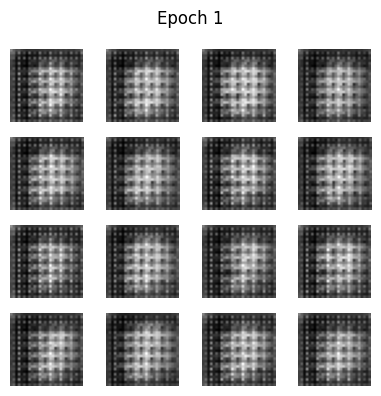

100%|██████████| 100/100 [02:16<00:00,  1.37s/it]


Epoch 2/10 completada


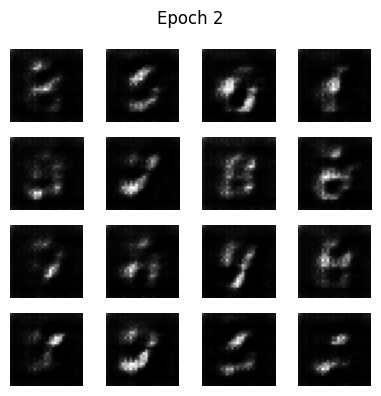

100%|██████████| 100/100 [02:19<00:00,  1.39s/it]


Epoch 3/10 completada


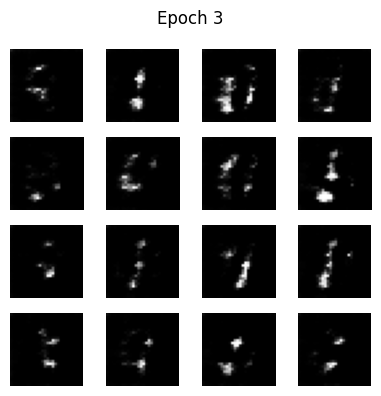

100%|██████████| 100/100 [02:17<00:00,  1.37s/it]


Epoch 4/10 completada


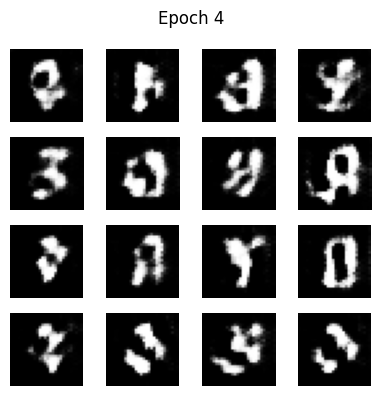

100%|██████████| 100/100 [02:14<00:00,  1.35s/it]


Epoch 5/10 completada


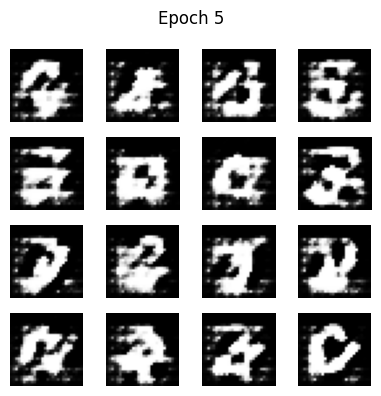

100%|██████████| 100/100 [02:03<00:00,  1.24s/it]


Epoch 6/10 completada


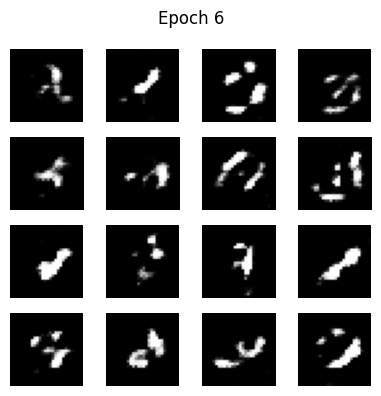

100%|██████████| 100/100 [02:06<00:00,  1.27s/it]


Epoch 7/10 completada


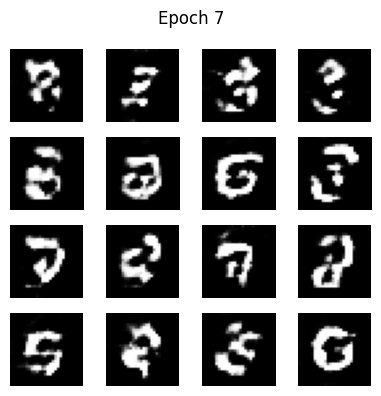

100%|██████████| 100/100 [02:07<00:00,  1.27s/it]


Epoch 8/10 completada


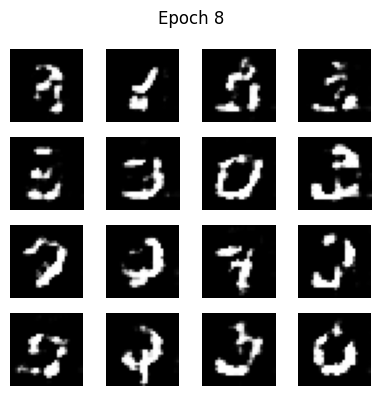

100%|██████████| 100/100 [02:07<00:00,  1.28s/it]


Epoch 9/10 completada


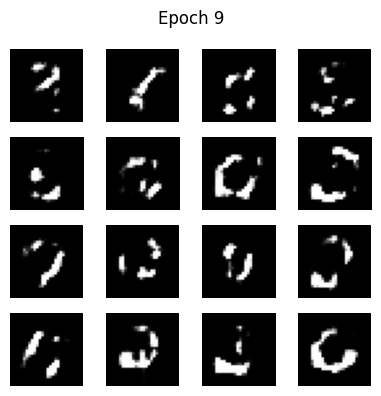

100%|██████████| 100/100 [02:04<00:00,  1.24s/it]


Epoch 10/10 completada


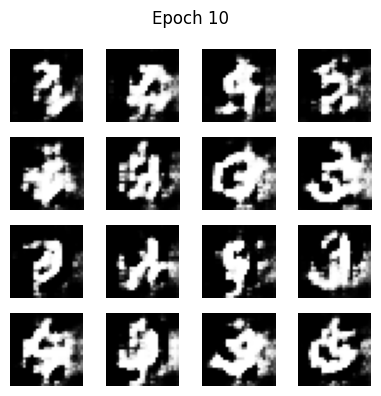

100%|██████████| 10/10 [22:08<00:00, 132.85s/it]


In [59]:
from tqdm import tqdm
# Entrenar
seed = tf.random.normal([16, z_dim])
for epoch in tqdm(range(epochs)):
    for image_batch in tqdm(dataset):
        train_step(image_batch)

    print(f"Epoch {epoch+1}/{epochs} completada")
    generate_and_save_images(generator, epoch, seed)


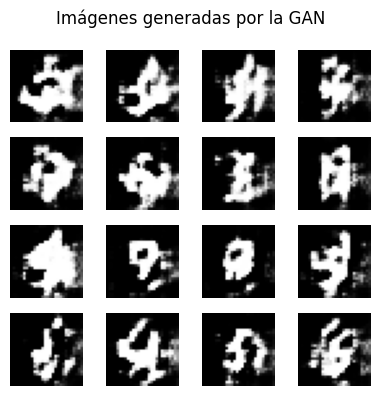

In [60]:
# Generar 16 imágenes nuevas después del entrenamiento
test_noise = tf.random.normal([16, z_dim])
generated_images = generator(test_noise, training=False)

# Mostrar imágenes generadas
def plot_generated_images(images):
    images = (images + 1) / 2.0  # volver a [0,1]
    fig = plt.figure(figsize=(4, 4))
    for i in range(images.shape[0]):
        plt.subplot(4, 4, i + 1)
        plt.imshow(images[i, :, :, 0], cmap='gray')
        plt.axis('off')
    plt.suptitle("Imágenes generadas por la GAN")
    plt.tight_layout()
    plt.show()

plot_generated_images(generated_images)
